## Linear model: FOGD and NZK ZOGD

In [ ]:
import torch
import torch.nn as nn
from matplotlib import pyplot as plt
import numpy as np

import copy, os, time
from scipy.io import loadmat, savemat

torch.manual_seed(0)

degree = 2
sample_num = 100

distribution = 'mixiture' # 't' or 'Laplace', 'normal'

eta_fo = 1e-3  # FOGD step size
eta_zo = 1e-3  # ZOGD step size
theta_init = torch.normal(mean=0, std=1, size=(degree, 1)) 

In [2]:
output_folder = os.path.join('output_linear_zo_fo_ntk_distribution', 'distribution_{}_degree_{}'.format(distribution, degree))
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

In [3]:
def target_linear_function(x: torch.tensor, weight: torch.tensor, noise_value, noise = False):
    # sample gaussian noise
    if noise:
        return x @ weight + noise_value
    else:
        return x @ weight

In [4]:
noise_value = torch.normal(mean=0, std=1, size=(sample_num, 1)) / 50.0 # noise value for gt function

theta_gt = torch.randint(1, 10, (degree, 1), dtype=torch.float32)


# initialize several Data Points between [1, 10]
# sample x from a sphere
data_sample = torch.rand(size=(sample_num, degree))
data_sample = data_sample / data_sample.norm(dim=1, keepdim=True, p=2)
target_gt = target_linear_function(data_sample, theta_gt, noise_value, noise=True)

In [6]:
iteration_total = 16000
function_record_iteration_list = [0, 49, 99, 199, 999, 1999, 2999, 3999, iteration_total-1]

## FOGD

In [7]:
fo_theta = copy.deepcopy(theta_init)

f_0 = data_sample @ fo_theta

NTK_kernal_fo = data_sample @ data_sample.t()

f_fo_list = torch.Tensor([])

loss_list_fo = torch.tensor([])
f_diff_list_fo = torch.tensor([])
for i in range(iteration_total):
    loss_0 = 1/2 * (f_0 - target_gt).pow(2).mean()
    loss_list_fo = torch.cat((loss_list_fo, loss_0.view(1)))

    f_1 = f_0 - eta_fo / sample_num *  NTK_kernal_fo.T @ (f_0 - target_gt)
    
    f_diff = f_1 - f_0
    
    if i in function_record_iteration_list:
        f_fo_list = torch.cat((f_fo_list, f_0.unsqueeze(0)))
    
    f_0 = f_1
    f_diff_list_fo = torch.cat((f_diff_list_fo, f_diff.view(1, -1)))
    

    

## NZK ZOGD

In [ ]:
data_sample = data_sample.cuda()

NZK_dict = {}
parameters = [1.0, 10, 0.5, 1000, 0.605]
for idx, distribution in enumerate(['normal', 't', 'Laplace', 't', "Laplace"]):
    NZK_list_sample = torch.tensor([]).cuda()
    for i in range(10000):
        if distribution == 'normal':
            z = torch.normal(0.0, parameters[idx], size=(1, degree)).cuda()
        elif distribution == 't':
            z = torch.tensor(np.random.standard_t(parameters[idx], size=(1, degree)), dtype=torch.float32).cuda()
        elif distribution == 'Laplace':
            z = torch.tensor(np.random.laplace(0, parameters[idx], size=(1, degree)), dtype=torch.float32).cuda()
        else:
            raise ValueError('distribution not supported')
        z = z.repeat(sample_num, 1)
        
        first_term = z @ data_sample.T
        second_term = z @ data_sample.T
        third_term = z @ z.T
        
        NZK_temp = first_term.T * second_term * third_term

        NZK_list_sample = torch.cat((NZK_list_sample, NZK_temp.unsqueeze(0)))

    NZK_kernal_zo = NZK_list_sample.mean(dim=0).cpu()
    NZK_dict[distribution+str(parameters[idx])] = NZK_kernal_zo
    
data_sample = data_sample.cpu()

In [11]:

f_diff_zo_dict = {}
f_zo_dict = {}
loss_zo_dict = {}

for param, distribution in zip(parameters, ['normal', 't', 'Laplace', 't', "Laplace"]):
    zo_theta = copy.deepcopy(theta_init)
    f_0 = data_sample @ zo_theta
    f_diff_list_zo = torch.tensor([])
    loss_list_zo = torch.tensor([])
    f_zo_list = torch.Tensor([])
    NZK_kernal_zo = NZK_dict[distribution+str(param)]

    for i in range(iteration_total):
        loss_0 = 1/2 * (f_0 - target_gt).pow(2).mean()
        loss_list_zo = torch.cat((loss_list_zo, loss_0.view(1)))
        
        f_1 = f_0 - eta_zo / sample_num * NZK_kernal_zo.T @ (f_0 - target_gt)
        
        f_diff = f_1 - f_0
        
        if i in function_record_iteration_list:
            f_zo_list = torch.cat((f_zo_list, f_0.unsqueeze(0)))
        
        f_0 = f_1
        f_diff_list_zo = torch.cat((f_diff_list_zo, f_diff.view(1, -1)))
    
    f_diff_zo_dict[distribution+str(param)] = f_diff_list_zo
    f_zo_dict[distribution+str(param)] = f_zo_list
    loss_zo_dict[distribution+str(param)] = loss_list_zo

## Plots (2D)

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

from matplotlib import cm
from mpl_toolkits.mplot3d.axes3d import get_test_data
from mpl_toolkits.axes_grid1 import make_axes_locatable
from brokenaxes import brokenaxes

## Loss

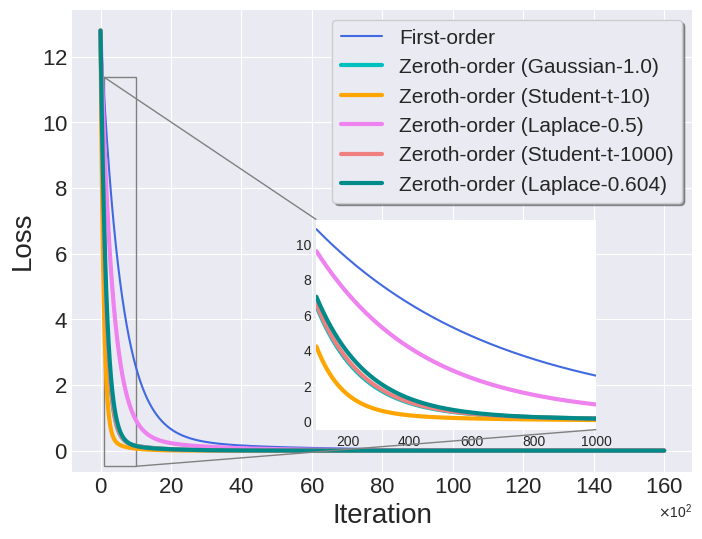

In [17]:
# plot the loss_list_fo and loss_list_zo
plt.style.use('seaborn-v0_8-darkgrid')
sf = plt.figure(figsize=(8,6))
ax = sf.add_subplot()
plt.plot(loss_list_fo.detach().numpy(),color='royalblue',label='First-order')
plt.plot(loss_zo_dict['normal1.0'].detach().numpy(), color='c',label='Zeroth-order (Gaussian-1.0)', linewidth=3)
plt.plot(loss_zo_dict['t10'].detach().numpy(),color='orange',label='Zeroth-order (Student-t-10)', linewidth=3)
plt.plot(loss_zo_dict['Laplace0.5'].detach().numpy(),color='violet',label='Zeroth-order (Laplace-0.5)', linewidth=3)
plt.plot(loss_zo_dict['t1000'].detach().numpy(),color='lightcoral',label='Zeroth-order (Student-t-1000)', linewidth=3)
plt.plot(loss_zo_dict['Laplace0.605'].detach().numpy(),color='darkcyan',label='Zeroth-order (Laplace-0.604)', linewidth=3)
#


plt.tick_params(axis='both', which='major', top='on', right='on', direction='in', labelsize=16)
plt.ticklabel_format(style='sci', scilimits=(-3,2), axis='y',useMathText=True)
plt.ticklabel_format(style='sci', scilimits=(2,2), axis='x',useMathText=True)
plt.legend(fancybox=True, shadow=True,fontsize=15, frameon=True)
# do not show x-axis linearly
# show the 0, 50, 100, 200, 1000, 2000, 3000, 4000, 16000 iteration equally
# plt.xticks([0, 2000, 4000, 8000, 12000, 16000], ['0', '2000', '4000', '8000', '12000', '16000'])
plt.xlabel('Iteration', fontsize=20)
plt.ylabel('Loss', fontsize=20)


# --------------------- zoom ---------------------
xlim_1, xlim_2 = 100, 1000
ax_zoom = sf.add_axes([0.43, 0.18, 0.35, 0.35], facecolor='w')
plt.plot(np.arange(xlim_1,xlim_2,1), loss_list_fo.detach().numpy()[xlim_1:xlim_2],color='royalblue',label='First-order')
plt.plot(np.arange(xlim_1,xlim_2,1), loss_zo_dict['normal1.0'].detach().numpy()[xlim_1:xlim_2], color='c',label='Zeroth-order (Gaussian-1.0)', linewidth=3)
plt.plot(np.arange(xlim_1,xlim_2,1), loss_zo_dict['t10'].detach().numpy()[xlim_1:xlim_2],color='orange',label='Zeroth-order (Student-t-10)', linewidth=3)
plt.plot(np.arange(xlim_1,xlim_2,1), loss_zo_dict['Laplace0.5'].detach().numpy()[xlim_1:xlim_2],color='violet',label='Zeroth-order (Laplace-0.5)', linewidth=3)
plt.plot(np.arange(xlim_1,xlim_2,1), loss_zo_dict['t1000'].detach().numpy()[xlim_1:xlim_2],color='lightcoral',label='Zeroth-order (Student-t-1000)', linewidth=3)
plt.plot(np.arange(xlim_1,xlim_2,1), loss_zo_dict['Laplace0.605'].detach().numpy()[xlim_1:xlim_2],color='darkcyan',label='Zeroth-order (Laplace-0.605)', linewidth=3)
# do not show blank part in the zoomed part
ax_zoom.set_xlim(xlim_1, xlim_2)
mark_inset(ax, ax_zoom, loc1=4, loc2=2, fc="none", ec="0.5", )




plt.show()

sf.savefig(os.path.join(output_folder,'loss.pdf'), bbox_inches='tight')

## Final fit along $x_1$

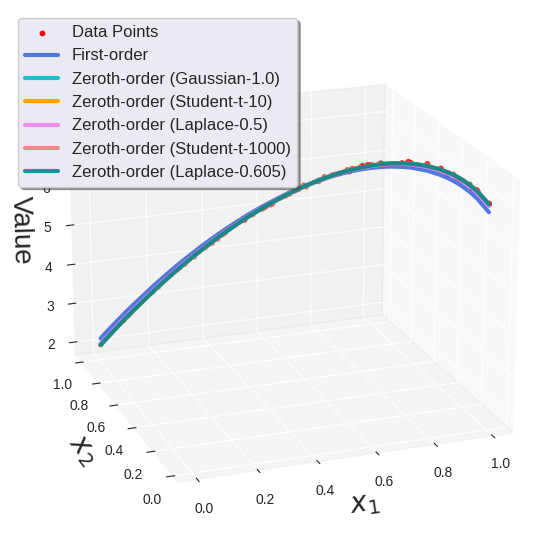

In [19]:
# plot the target function as a str
plt.style.use('seaborn-v0_8-darkgrid')
fig = plt.figure(figsize=(7,7))
f3d = fig.add_subplot(projection='3d')
# set background color as white
f3d.set_facecolor('white')

sort_idx = data_sample[:, 0].sort().indices
sort_data_sample = data_sample[sort_idx]
sort_target_gt = target_gt[sort_idx]
sort_f_fo_list = f_fo_list[-1][sort_idx]
sort_f_zo_normal = f_zo_dict['normal1.0'][-1][sort_idx]
sort_f_zo_t = f_zo_dict['t10'][-1][sort_idx]
sort_f_zo_Laplace = f_zo_dict['Laplace0.5'][-1][sort_idx]
sort_f_zo_t_100k = f_zo_dict['t1000'][-1][sort_idx]
sort_f_zo_Laplace_2 = f_zo_dict['Laplace0.605'][-1][sort_idx]


f3d.scatter(sort_data_sample[:, 0].detach().numpy(), sort_data_sample[:, 1].detach().numpy(), sort_target_gt.detach().numpy(), color='r', label='Data Points', s= 10)
f3d.plot(sort_data_sample[:, 0].detach().numpy(), sort_data_sample[:, 1].detach().numpy(), sort_f_fo_list.squeeze().detach().numpy(), 'royalblue', label='First-order', linewidth=3, alpha=0.9)
f3d.plot(sort_data_sample[:, 0].detach().numpy(), sort_data_sample[:, 1].detach().numpy(), sort_f_zo_normal.squeeze().detach().numpy(), 'c', label='Zeroth-order (Gaussian-1.0)', linewidth=3, alpha=0.9)
f3d.plot(sort_data_sample[:, 0].detach().numpy(), sort_data_sample[:, 1].detach().numpy(), sort_f_zo_t.squeeze().detach().numpy(), 'orange', label='Zeroth-order (Student-t-10)', linewidth=3, alpha=1.0)
f3d.plot(sort_data_sample[:, 0].detach().numpy(), sort_data_sample[:, 1].detach().numpy(), sort_f_zo_Laplace.squeeze().detach().numpy(), 'violet', label='Zeroth-order (Laplace-0.5)', linewidth=3, alpha=0.9)
f3d.plot(sort_data_sample[:, 0].detach().numpy(), sort_data_sample[:, 1].detach().numpy(), sort_f_zo_t_100k.squeeze().detach().numpy(), 'lightcoral', label='Zeroth-order (Student-t-1000)', linewidth=3, alpha=0.9)
f3d.plot(sort_data_sample[:, 0].detach().numpy(), sort_data_sample[:, 1].detach().numpy(), sort_f_zo_Laplace_2.squeeze().detach().numpy(), 'darkcyan', label='Zeroth-order (Laplace-0.605)', linewidth=3, alpha=0.9)

f3d.set_xlabel(r'$x_1$', fontsize=20)
f3d.set_ylabel(r'$x_2$', fontsize=20)
f3d.set_zlabel('Value', fontsize=20)
f3d.tick_params(axis='both', which='major', top='on', right='on', direction='in', labelsize=10)
f3d.legend(fancybox=True, shadow=True,fontsize=12, frameon=True, loc = 'upper left')


azim = int(-110)
dist = int(10)
elev = int(20)
if azim is not None:
    f3d.azim = azim
if dist is not None:
    f3d.dist = dist
if elev is not None:
    f3d.elev = elev

plt.show()
# save the figure
fig.savefig(os.path.join(output_folder,'final_optimization_3d.pdf'), bbox_inches='tight')

## Function evolution

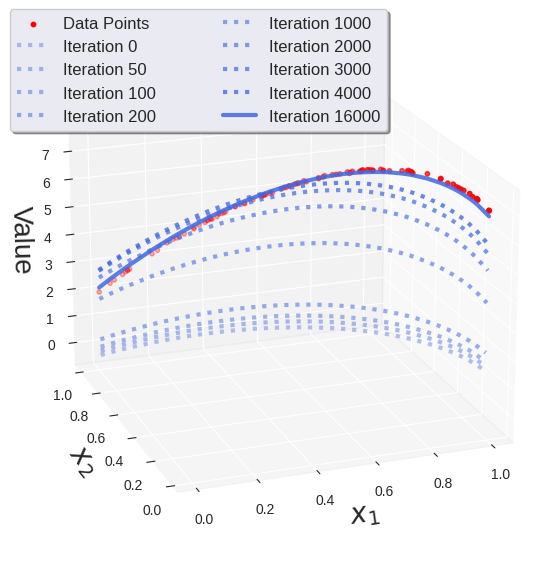

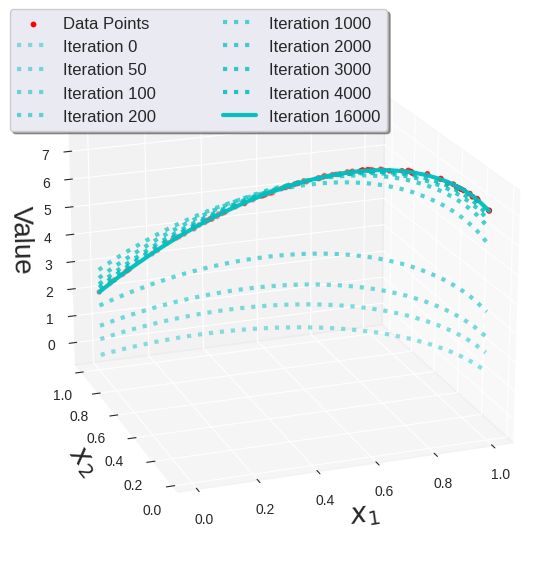

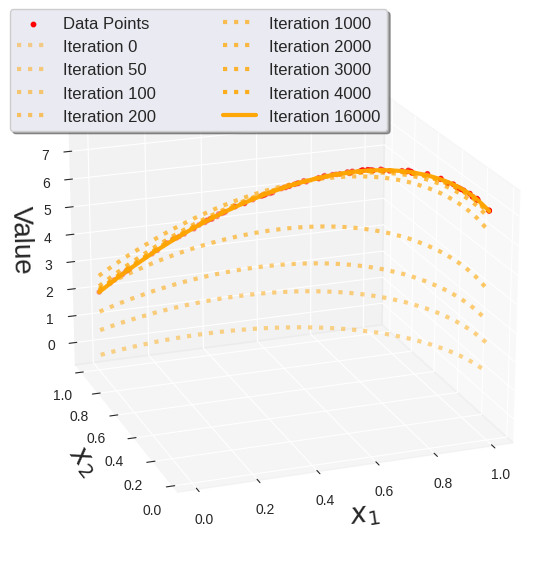

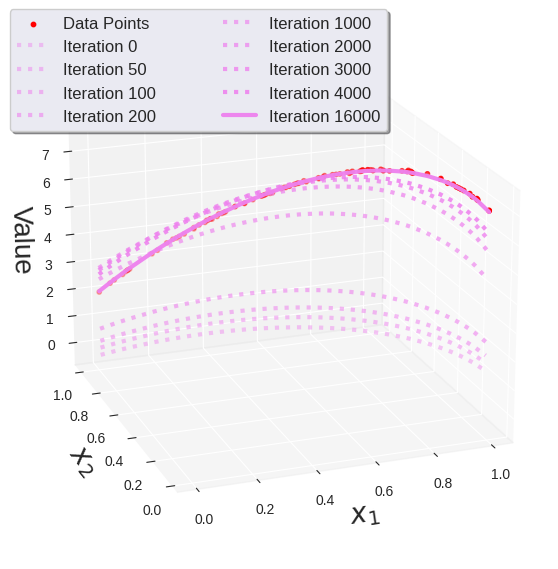

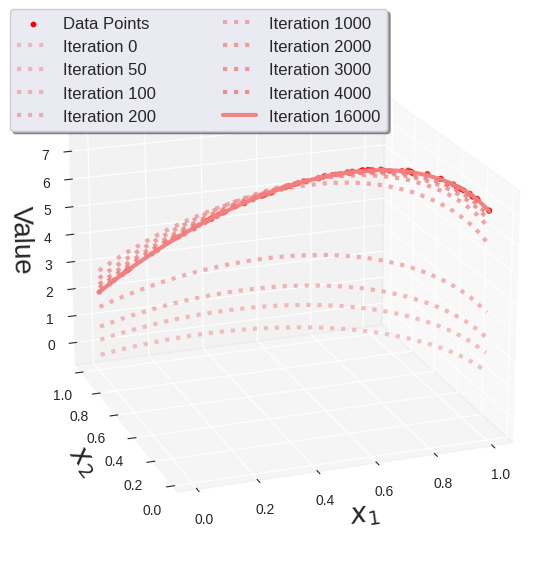

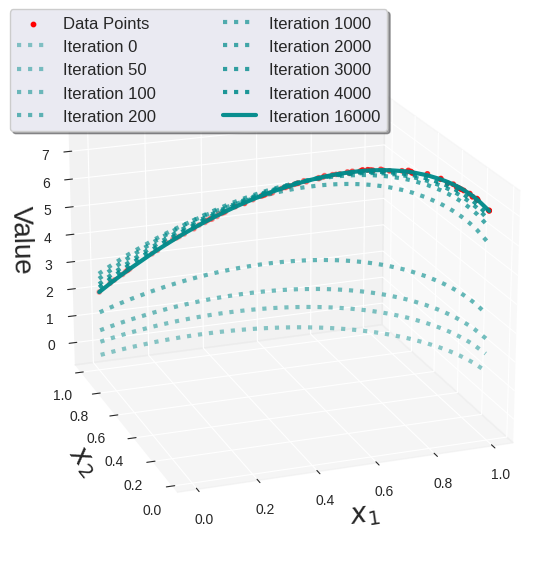

In [20]:
evolution_vis_style = 2 # do not use style 1 for clear visualization
# ---------------------------------------- style 1 ----------------------------------------
if evolution_vis_style == 1:
    rows = 2
    cols = len(f_zo_list)
    assert len(f_zo_list) == len(f_fo_list) == len(function_record_iteration_list)

    grid = plt.GridSpec(rows, cols, wspace = 0.05, hspace = 0.05)
    fig = plt.figure(figsize=(32,8))

    opacity = 0.1

    for i in range(len(function_record_iteration_list)):
        if i != 9:
            linestyle = 'dotted'
        else:
            linestyle = 'solid'
            
        # plot zo
        ax = fig.add_subplot(grid[0, i]) 
        ax.scatter(data_sample[:, 0].detach().numpy(), target_gt.detach().numpy(), color='r', label='Data Points', s= 20)
        ax.plot(data_sample[:, 0].detach().numpy(), f_zo_list[i].detach().numpy(), 'c', label='Zero-Order optimization', alpha=opacity, linestyle=linestyle)
        ax.set_title('Iteration {}'.format(function_record_iteration_list[i] + 1 if i != 0 else 0))
        ax.set_xticklabels([])
        if i == 0:
            ax.set_ylabel('Y', fontsize=20)
        else:
            ax.set_yticklabels([])
        ax.tick_params(axis='both', which='major', top='on', right='on', direction='in')
        ax.legend(fancybox=True, shadow=True,fontsize=20)
        
        # plot fo
        ax = fig.add_subplot(grid[1, i])
        ax.scatter(data_sample[:, 0].detach().numpy(), target_gt.detach().numpy(), color='r', label='Data Points', s= 20)
        ax.plot(data_sample[:, 0].detach().numpy(), f_fo_list[i].detach().numpy(), 'royalblue', label='First-Order optimization', alpha=opacity, linestyle=linestyle)
        
        ax.set_xlabel('X', fontsize=20)
        if i == 0:
            ax.set_ylabel('Y', fontsize=20)
        else:
            ax.set_yticklabels([])
        ax.tick_params(axis='both', which='major', top='on', right='on', direction='in')
        ax.legend(fancybox=True, shadow=True,fontsize=20)
        opacity += 0.1

# ---------------------------------------- style 2 ----------------------------------------

else:
    assert len(f_zo_list) == len(f_fo_list) == len(function_record_iteration_list)
        
    sort_idx = data_sample[:, 0].sort().indices
    sort_data_sample = data_sample[sort_idx]
    sort_target_gt = target_gt[sort_idx]


    fig = plt.figure(figsize=(7,7))
    opacity = 0.4
    
    # set background color as white
    fig.patch.set_facecolor('white')

    # plot zo
    ax = fig.add_subplot(projection='3d')
    ax.set_facecolor('white')
    ax.scatter(sort_data_sample[:, 0].detach().numpy(), sort_data_sample[:, 1].detach().numpy(), sort_target_gt.detach().numpy(), color='r', label='Data Points', s= 10)

    for i in range(len(function_record_iteration_list)):
        if i != 8:
            linestyle = 'dotted'
        else:
            linestyle = 'solid'

        sort_f_fo_list = f_fo_list[i][sort_idx]
        ax.plot(sort_data_sample[:, 0].detach().numpy(), sort_data_sample[:, 1].detach().numpy(), sort_f_fo_list.squeeze().detach().numpy(), 'royalblue', 
                label=f'Iteration {function_record_iteration_list[i] + 1 if i!=0 else 0}', alpha=opacity, linestyle=linestyle,  linewidth=3)
        ax.set_xlabel(r'$x_1$', fontsize=20)
        ax.set_ylabel(r'$x_2$', fontsize=20)
        ax.set_zlabel('Value', fontsize=20)
        
        ax.tick_params(axis='both', which='major', top='on', right='on', direction='in', labelsize=10)
        ax.legend(fancybox=True, shadow=True,fontsize=12, loc='upper left', bbox_to_anchor=(0, 1.02, 0.7, -0.0), ncol=2, mode="expand", borderaxespad=0, frameon=True)
        ax.set_facecolor('white')
        opacity *= 1.1
    
    azim = int(-110)
    dist = int(10)
    elev = int(20)
    if azim is not None:
        ax.azim = azim
    if dist is not None:
        ax.dist = dist
    if elev is not None:
        ax.elev = elev
        
    fig.savefig(os.path.join(output_folder,f'Evolution_process_style{evolution_vis_style}_dist_fo.pdf'), bbox_inches='tight')

    # plot fo
    colors = ['c', 'orange', 'violet', 'lightcoral', 'darkcyan']
    for d_idx, distribution in enumerate(['normal', 't', 'Laplace', 't', "Laplace"]):
        fig = plt.figure(figsize=(7,7))
        # set background color as white
        fig.patch.set_facecolor('white')
        ax = fig.add_subplot(projection='3d')
        opacity = 0.45
        ax.scatter(sort_data_sample[:, 0].detach().numpy(), sort_data_sample[:, 1].detach().numpy(), sort_target_gt.detach().numpy(), color='r', label='Data Points', s= 10)
        for i in range(len(function_record_iteration_list)):
            if i != 8:
                linestyle = 'dotted'
            else:
                linestyle = 'solid'
            
            sort_f_zo_list = f_zo_dict[distribution+str(parameters[d_idx])][i][sort_idx]
            ax.plot(sort_data_sample[:, 0].detach().numpy(), sort_data_sample[:, 1].detach().numpy(), sort_f_zo_list.squeeze().detach().numpy(), colors[d_idx], 
                    label=f'Iteration {function_record_iteration_list[i] + 1 if i!=0 else 0}', alpha=opacity, linestyle=linestyle, linewidth=3)
            ax.set_xlabel(r'$x_1$', fontsize=20)
            ax.set_ylabel(r'$x_2$', fontsize=20)
            ax.set_zlabel('Value', fontsize=20)
            ax.tick_params(axis='both', which='major', top='on', right='on', direction='in', labelsize=10)
            ax.legend(fancybox=True, shadow=True,fontsize=12, loc='upper left', bbox_to_anchor=(0, 1.02, 0.7, -0.0), ncol=2, mode="expand", borderaxespad=0, frameon=True)
            ax.set_facecolor('white')
            opacity *= 1.1
    
        azim = int(-110)
        dist = int(10)
        elev = int(20)
        if azim is not None:
            ax.azim = azim
        if dist is not None:
            ax.dist = dist
        if elev is not None:
            ax.elev = elev

        fig.savefig(os.path.join(output_folder,f'Evolution_process_style{evolution_vis_style}_dist_{distribution}_{parameters[d_idx]}.pdf'), bbox_inches='tight')

## NTK and NZK heatmaps

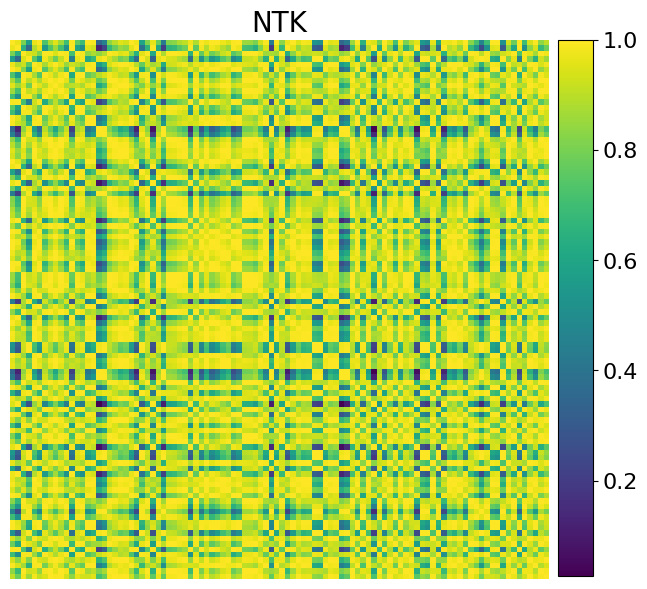

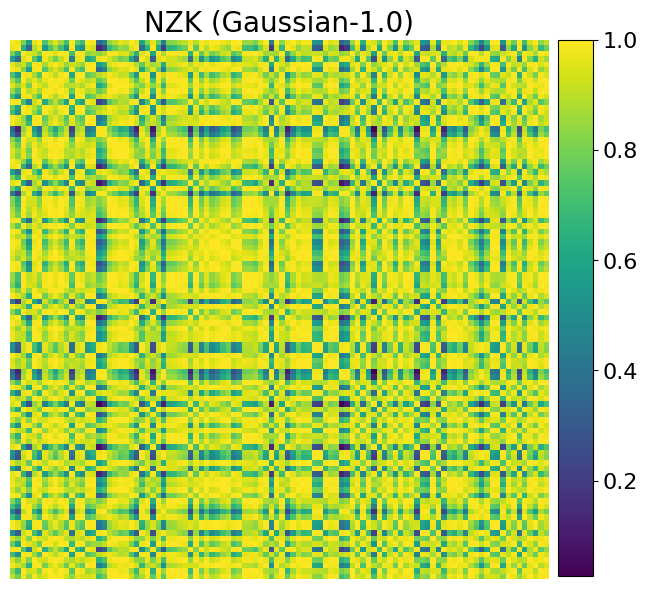

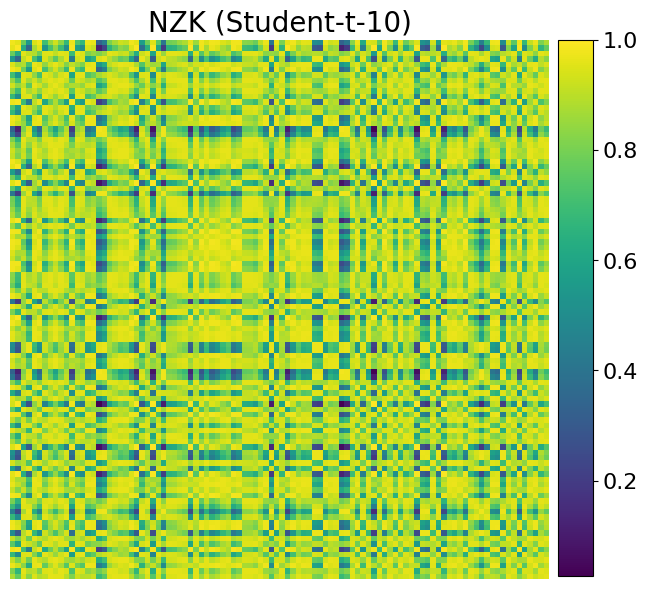

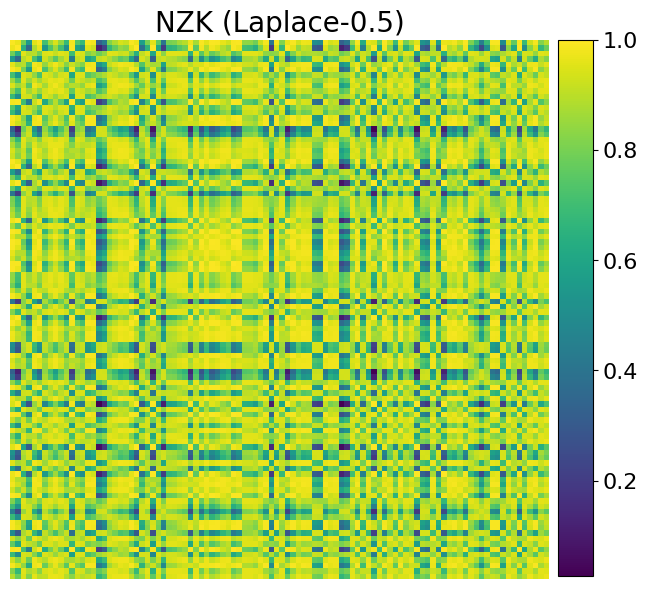

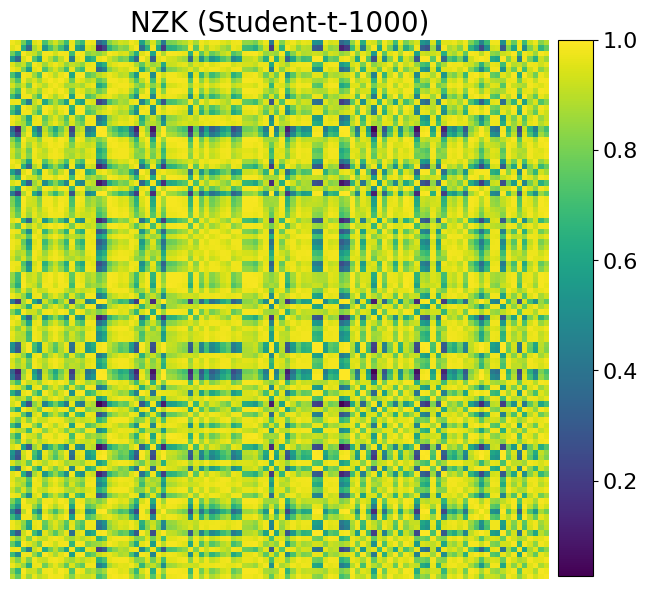

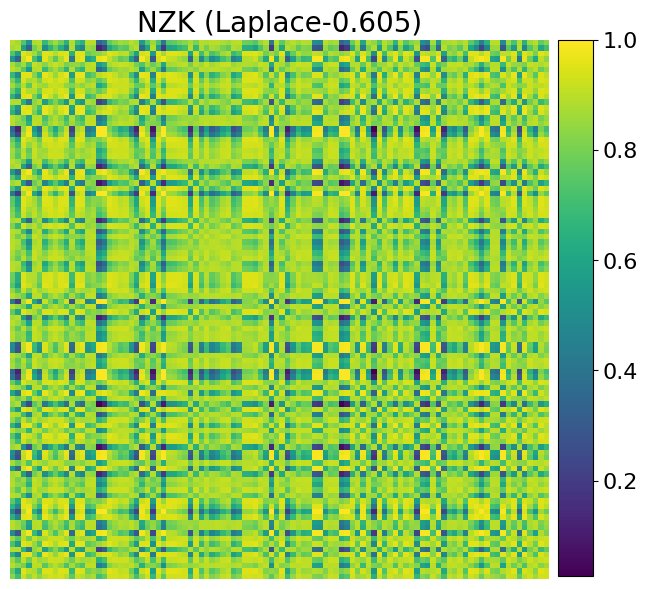

In [22]:
# return to defualt style
from matplotlib.ticker import FormatStrFormatter
plt.style.use('default')


fig = plt.figure(figsize=(7,7))

ax = fig.add_subplot()
norm_fo = plt.Normalize(NTK_kernal_fo.min(), NTK_kernal_fo.max())
ax.imshow(NTK_kernal_fo.detach().numpy(), label='NTK', norm=norm_fo)
ax.title.set_text('NTK')
ax.title.set_fontsize(20)
ax.axis('off')
cbar_ax = fig.add_axes([0.91, 0.115, 0.05, 0.765])
cbar_ax.tick_params(labelsize=16)
sm = plt.cm.ScalarMappable(cmap=cm.viridis, norm=norm_fo)
sm.set_array([])
fig.colorbar(sm, cax=cbar_ax)
fig.savefig(os.path.join(output_folder,'NTK.pdf'), bbox_inches='tight')

distribution_param = ['Gaussian-1.0', 'Student-t-10', 'Laplace-0.5', 'Student-t-1000', 'Laplace-0.605']

for idx, distribution in enumerate(['normal1.0', 't10', 'Laplace0.5', 't1000', 'Laplace0.605']):
    fig = plt.figure(figsize=(7,7))
    ax = fig.add_subplot()
    norm = plt.Normalize(NZK_dict[distribution].min(), NZK_dict[distribution].max())
    ax.imshow(NZK_dict[distribution].detach().numpy(), label=f'NZK Kernel of Zero-Order ({distribution})', norm=norm)
    ax.title.set_text(f'NZK ({distribution_param[idx]})')
    ax.title.set_fontsize(20)
    ax.axis('off')
    cbar_ax_normal = fig.add_axes([0.91, 0.115, 0.05, 0.765])
    cbar_ax_normal.tick_params(labelsize=16)
    # show in float format
    cbar_ax_normal.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    sm.set_array([])
    fig.colorbar(sm, cax=cbar_ax_normal)


    fig.savefig(os.path.join(output_folder, f'NZK_dist_{distribution_param[idx]}.pdf'), bbox_inches='tight')